# Entendendo o projeto

## Contexto e objetivo

A Model Fitness busca desenvolver uma estratégia de interação e retenção de clientes baseada em dados. Como um aluno pode deixar de frequentar a academia antes de cancelar formalmente o contrato, a análise deve identificar sinais de risco de evasão com antecedência. Neste projeto, considera-se o churn indicado na base disponibilizada, com foco em prever quais clientes têm maior probabilidade de abandonar a academia no mês seguinte.

## Etapas da análise

A partir dos perfis dos clientes registrados em `gym_churn_us.csv`, serão realizadas a inspeção e a análise exploratória dos dados para compreender o comportamento dos alunos e identificar possíveis fatores associados ao churn. Em seguida, serão treinados e comparados modelos de classificação para estimar o risco de evasão. Também serão aplicados métodos de agrupamento para segmentar os clientes e descrever os perfis mais marcantes.

Por fim, os resultados serão usados para apontar os fatores que mais influenciam a rotatividade, identificar grupos prioritários para ações de retenção e propor medidas para melhorar o engajamento e o serviço. A análise também buscará destacar outros padrões relevantes nas interações dos clientes com a academia.

# Bibliotecas

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans


# 1. Carregamento e Inspeção Inicial da Base de Dados

In [2]:
# Localização da base de dados
caminhos_base = [
    Path("../datasets/gym_churn_us.csv"),
    Path("datasets/gym_churn_us.csv"),
    Path("gym_churn_us.csv"),
]

caminho_base = next((p for p in caminhos_base if p.exists()), None)

if caminho_base is None:
    raise FileNotFoundError(
        "A base 'gym_churn_us.csv' não foi encontrada. "
        "Coloque o arquivo em '../datasets/', 'datasets/' ou na mesma pasta do notebook."
    )


dados_academia = pd.read_csv(caminho_base)
print(f"Base carregada de: {caminho_base.resolve()}")
print(f"Dimensões: {dados_academia.shape[0]} linhas x {dados_academia.shape[1]} colunas")


Base carregada de: C:\Users\Z4r4k1\Downloads\meus_projetos\model_fitness_academias\datasets\gym_churn_us.csv
Dimensões: 4000 linhas x 14 colunas


In [3]:
dados_academia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

In [4]:
dados_academia.sample(10)

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
362,0,1,0,0,1,12,0,31,73.662913,11.0,2,2.023342,1.921443,0
2177,1,1,1,1,1,12,0,25,9.054828,9.0,3,1.060014,1.004836,0
1151,0,1,1,1,1,12,1,29,257.939031,11.0,5,1.902582,1.789563,0
61,0,1,1,0,1,6,0,32,55.774418,5.0,6,0.813561,0.874677,0
824,1,1,1,0,1,1,1,33,162.890882,1.0,12,0.456113,0.547041,0
1165,1,1,1,1,1,12,0,27,192.128599,10.0,4,1.183444,1.225739,0
2540,1,0,0,0,1,6,0,29,217.166218,6.0,8,1.236886,1.132979,0
276,0,1,0,0,1,12,0,30,165.977742,12.0,3,2.881731,2.909448,0
211,1,1,0,0,1,1,1,25,139.984692,1.0,0,2.375718,1.831002,1
198,0,1,1,1,1,12,1,27,111.265846,12.0,5,0.792885,0.876397,0


# 2. Análise Exploratória dos Dados

In [5]:
dados_academia.describe()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


In [6]:
dados_academia.groupby('Churn').mean()


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
Churn,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


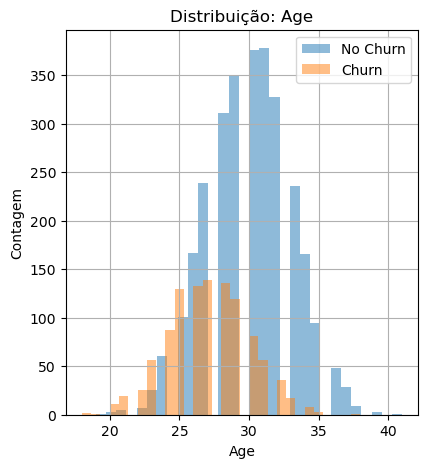

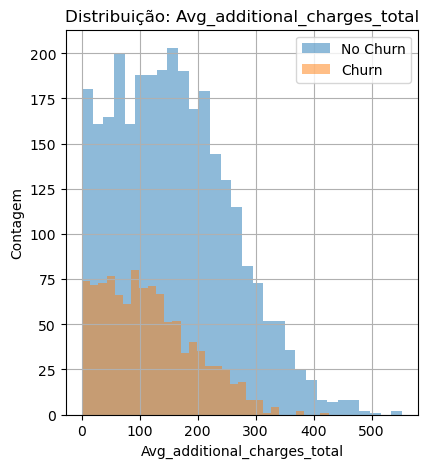

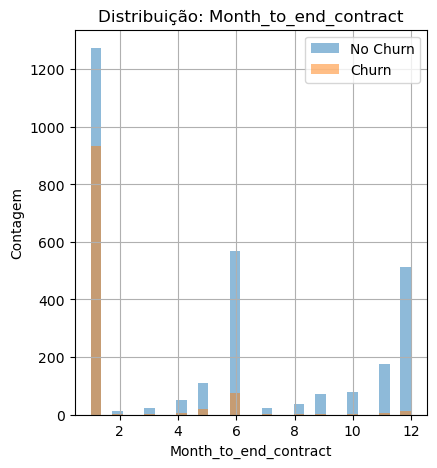

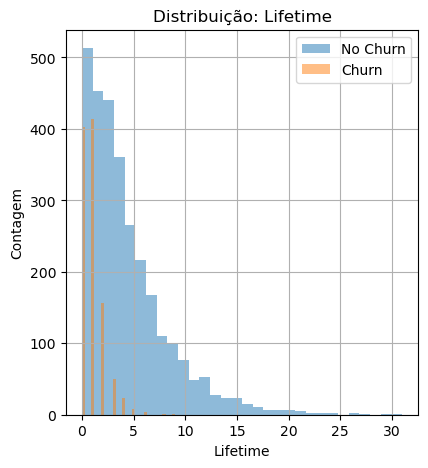

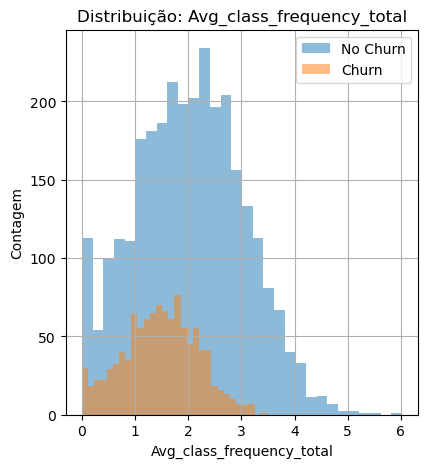

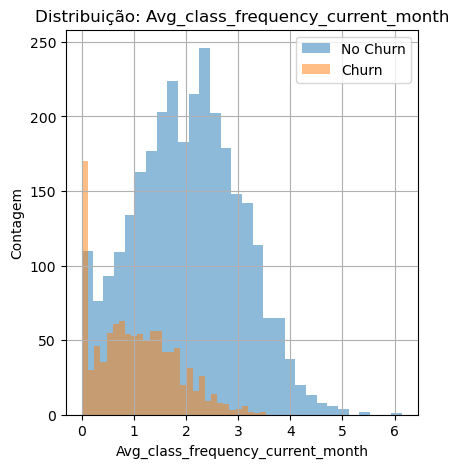

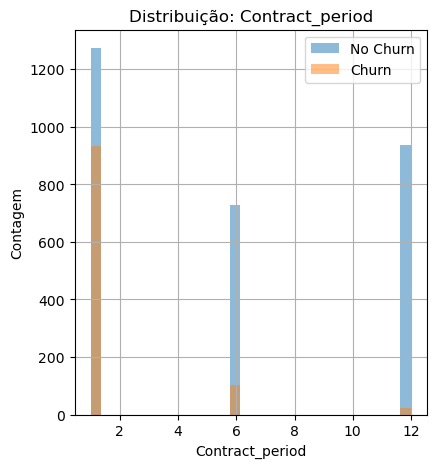

In [7]:
# Comparando a distribuição de cada variável entre membros que cancelaram e os que permaneceram
colunas_analise = ['Age', 'Avg_additional_charges_total', 'Month_to_end_contract', 'Lifetime', 'Avg_class_frequency_total', 'Avg_class_frequency_current_month', 'Contract_period']
for coluna in colunas_analise:
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    dados_academia[dados_academia['Churn'] == 0][coluna].hist(bins=30, alpha=0.5, label='No Churn')
    dados_academia[dados_academia['Churn'] == 1][coluna].hist(bins=30, alpha=0.5, label='Churn')
    plt.title(f'Distribuição: {coluna}')
    plt.xlabel(coluna)
    plt.ylabel('Contagem')
    plt.legend()
    plt.show()

In [8]:
dados_academia.corr()['Churn'].sort_values(ascending=False)

Churn                                1.000000
gender                               0.000708
Phone                               -0.001177
Near_Location                       -0.128098
Partner                             -0.157986
Promo_friends                       -0.162233
Group_visits                        -0.175325
Avg_additional_charges_total        -0.198697
Avg_class_frequency_total           -0.249715
Month_to_end_contract               -0.381393
Contract_period                     -0.389984
Age                                 -0.404735
Avg_class_frequency_current_month   -0.412348
Lifetime                            -0.438220
Name: Churn, dtype: float64

# 3. Modelagem Preditiva — Classificação de Cancelamento

In [9]:
# Separando atributos preditivos da variável-alvo (cancelamento)

atributos = dados_academia.drop(columns="Churn")
cancelamento = dados_academia["Churn"]

# Particionando em treino e teste, preservando a proporção de churn
atrib_treino, atrib_teste, canc_treino, canc_teste = train_test_split(
    atributos,
    cancelamento,
    test_size=0.2,
    random_state=42,
    stratify=cancelamento,
)

print(f"Treino: {atrib_treino.shape[0]} registros")
print(f"Teste: {atrib_teste.shape[0]} registros")


Treino: 3200 registros
Teste: 800 registros


In [10]:
# Normalização e treinamento — regressão logística

normalizador = StandardScaler()

atrib_treino_norm = normalizador.fit_transform(atrib_treino)
atrib_teste_norm = normalizador.transform(atrib_teste)

modelo_regressao = LogisticRegression(
    max_iter=1000,
    random_state=42
)

modelo_regressao.fit(atrib_treino_norm, canc_treino)

predicao_logistica = modelo_regressao.predict(atrib_teste_norm)


In [11]:
# Treinamento da floresta aleatória para classificação

modelo_floresta = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

modelo_floresta.fit(atrib_treino, canc_treino)

predicao_floresta = modelo_floresta.predict(atrib_teste)


In [12]:
# Métricas de desempenho — regressão logística

acuracia_log = accuracy_score(canc_teste, predicao_logistica)
relatorio_log = classification_report(canc_teste, predicao_logistica)
matriz_confusao_log = confusion_matrix(canc_teste, predicao_logistica)

print(f"Acurácia: {acuracia_log:.2f}")
print("Relatório de Classificação:")
print(relatorio_log)
print("Matriz de Confusão:")
print(matriz_confusao_log)


Acurácia: 0.93
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       588
           1       0.88      0.83      0.85       212

    accuracy                           0.93       800
   macro avg       0.91      0.89      0.90       800
weighted avg       0.92      0.93      0.92       800

Matriz de Confusão:
[[564  24]
 [ 36 176]]


In [13]:
# Métricas de desempenho — floresta aleatória

acuracia_floresta = accuracy_score(canc_teste, predicao_floresta)
relatorio_floresta = classification_report(canc_teste, predicao_floresta)
matriz_confusao_floresta = confusion_matrix(canc_teste, predicao_floresta)

print(f"Acurácia: {acuracia_floresta:.2f}")
print("Relatório de Classificação:")
print(relatorio_floresta)
print("Matriz de Confusão:")
print(matriz_confusao_floresta)


Acurácia: 0.92
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       588
           1       0.88      0.83      0.85       212

    accuracy                           0.92       800
   macro avg       0.91      0.89      0.90       800
weighted avg       0.92      0.92      0.92       800

Matriz de Confusão:
[[564  24]
 [ 37 175]]


**Os dois algoritmos apresentaram desempenho próximo, porém a regressão logística demonstrou leve vantagem nas métricas de precisão e recall, sendo a escolha mais adequada para este problema.**

# 4. Segmentação de Clientes via Agrupamento

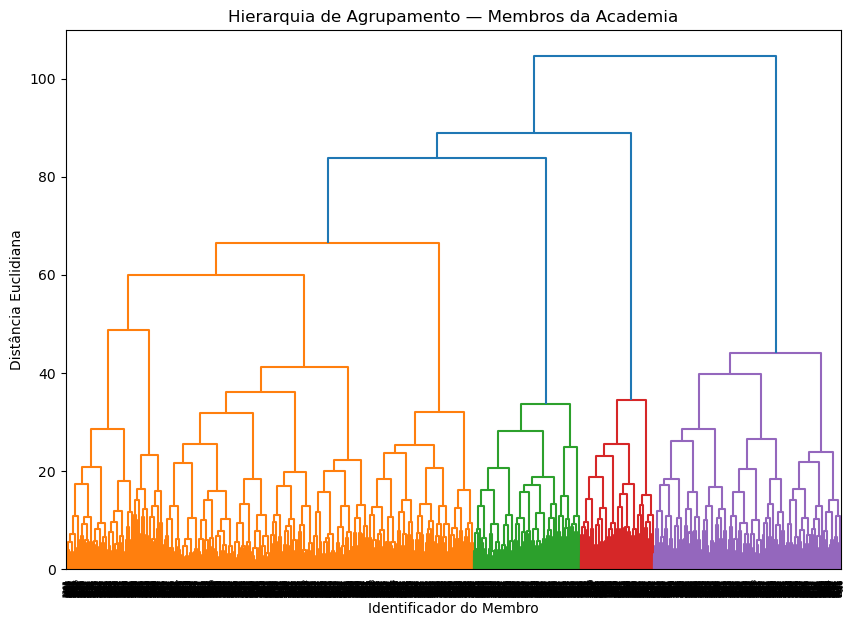

In [14]:
# Construção do dendrograma a partir das distâncias hierárquicas

# Padronização dos atributos para clustering
normalizador = StandardScaler()
atributos_norm = normalizador.fit_transform(atributos)
# Calculando a matriz de distâncias e renderizando o dendrograma
hierarquia = linkage(atributos_norm, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(hierarquia, orientation='top', distance_sort='descending', show_leaf_counts=False)
plt.title('Hierarquia de Agrupamento — Membros da Academia')
plt.xlabel('Identificador do Membro')
plt.ylabel('Distância Euclidiana')
plt.show()

In [15]:
# Ajuste do K-means e avaliação dos segmentos

agrupador = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

grupos = agrupador.fit_predict(atributos_norm)

print("Centros dos segmentos identificados:")
print(agrupador.cluster_centers_)

print("\nDistribuição de membros por segmento:")
print(pd.Series(grupos, name="Cluster").value_counts().sort_index())


Centros dos segmentos identificados:
[[-0.0278588  -2.33709981 -0.03969041 -0.50077301  0.04044077 -0.54333187
  -0.40057002 -0.21510214 -0.13818789 -0.53670774 -0.25168066 -0.22771021
  -0.2851342 ]
 [-0.02264151  0.27427071  0.50744744  0.38223124 -0.00968239  1.58345752
   0.28244785  0.22939937  0.1835304   1.56400406  0.25325325  0.1235338
   0.21226192]
 [-0.04678495  0.4236072   0.67124887  1.49716101 -0.01865807 -0.33390124
   0.09191891  0.01555589 -0.05185002 -0.3337055   0.00250951 -0.13940855
  -0.12273191]
 [-0.04405998  0.42788074 -0.48635196 -0.62282475 -0.00449101 -0.59278243
  -0.18424362 -0.29954841 -0.16273294 -0.57802878 -0.35908223 -0.62651596
  -0.70246823]
 [ 0.1498826   0.34877857 -0.45610491 -0.47647928  0.00532222 -0.41102445
   0.12675205  0.28990187  0.15161753 -0.41337784  0.38318904  1.02746121
   1.05509533]]

Distribuição de membros por segmento:
Cluster
0     544
1     936
2     646
3    1107
4     767
Name: count, dtype: int64


In [16]:
# Adicionando o cluster à base e descrevendo os segmentos

dados_academia = dados_academia.copy()
dados_academia["Cluster"] = grupos

perfil_clusters = dados_academia.groupby("Cluster").mean(numeric_only=True)
perfil_clusters


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
Cluster,,,,,,,,,,,,,,
0,0.496324,0.000000,0.466912,0.077206,0.915441,2.209559,0.215074,28.483456,133.630215,2.073529,2.781250,1.657657,1.466870,0.450368
1,0.498932,0.944444,0.740385,0.485043,0.900641,11.884615,0.551282,29.931624,164.625700,10.877137,4.674145,1.999110,1.990516,0.022436
2,0.486068,0.998452,0.823529,1.000000,0.899381,3.165635,0.456656,29.224458,141.868789,2.927245,3.739938,1.742540,1.636485,0.246130
3,0.488708,1.000000,0.242999,0.020777,0.902439,1.986450,0.320687,28.209575,131.151639,1.902439,2.391147,1.272203,1.029702,0.526649
4,0.585398,0.971317,0.259452,0.089961,0.903520,2.809648,0.477184,30.142112,161.875250,2.588005,5.147327,2.880231,2.881432,0.069100


In [17]:
# Taxa de cancelamento por segmento de clientes

taxa_cancelamento_grupo = (
    dados_academia.groupby("Cluster")["Churn"]
    .mean()
    .sort_index()
)

print("Taxa de cancelamento por segmento:")
print(taxa_cancelamento_grupo)


Taxa de cancelamento por segmento:
Cluster
0    0.450368
1    0.022436
2    0.246130
3    0.526649
4    0.069100
Name: Churn, dtype: float64


c:\Users\Z4r4k1\.conda\envs\tripleten\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


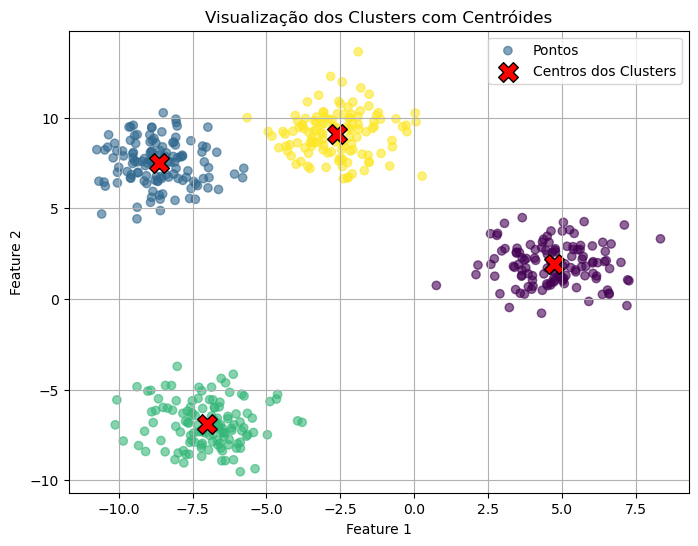

In [18]:
# Exemplo isolado de visualização de clusters com dados simulados

from sklearn.datasets import make_blobs

X, _ = make_blobs(
    n_samples=500,
    centers=4,
    cluster_std=1.2,
    random_state=42
)

kmeans_exemplo = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

labels = kmeans_exemplo.fit_predict(X)
centers = kmeans_exemplo.cluster_centers_

plt.figure(figsize=(8, 6))
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    cmap="viridis",
    alpha=0.6,
    label="Pontos"
)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c="red",
    s=200,
    marker="X",
    edgecolors="black",
    label="Centros dos Clusters"
)

plt.title("Visualização dos Clusters com Centróides")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()


# 5. A partir dos padrões identificados na análise, destacam-se quatro diretrizes estratégicas para reduzir o cancelamento, cada uma acompanhada de uma ação concreta de marketing:

##### 1. Estimular a Participação em Atividades Coletivas
##### Membros que frequentam aulas em grupo apresentam retenção consideravelmente maior. O vínculo criado com outros alunos e instrutores eleva o engajamento e reduz a propensão ao abandono.

##### Ação proposta: Desenvolver um programa de onboarding que inclua sessões de aula coletiva gratuitas nas primeiras semanas de matrícula, facilitando o contato social desde o início da jornada do aluno.

##### 2. Incentivar a Migração para Planos de Maior Duração
##### Contratos mensais concentram a maior parte dos cancelamentos. Clientes com compromissos mais longos tendem a permanecer mais tempo e a utilizar mais os serviços da academia.

##### Ação proposta: Oferecer desconto progressivo para renovações antecipadas, com condição especial de "10 meses pelo preço de 8" para clientes prestes a encerrar contratos curtos.

##### 3. Monitorar e Reativar Membros com Baixa Frequência
##### A frequência de visitas no mês corrente é um dos indicadores mais correlacionados ao churn. Alunos que reduzem a presença abaixo de duas vezes semanais sinalizam risco elevado de cancelamento.

##### Ação proposta: Implementar alertas automáticos para membros inativos por mais de quatro dias, acionando um contato personalizado com oferta de avaliação física ou acesso a aula experimental.

##### 4. Ampliar o Programa de Indicação e Parcerias
##### Alunos originados por indicação de colegas ou por convênios corporativos registram taxas de cancelamento menores e maior engajamento médio.

##### Ação proposta: Criar um programa de recompensas escalonável onde o indicante acumula créditos para serviços premium (nutricionista, fisioterapia, produtos) a cada novo membro ativo indicado por pelo menos seis meses.